In [2]:
import pandas as pd

# Load the dataset
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

print("Training tickets:", X_train.shape)
print("Testing tickets:", X_test.shape)

print("\nTraining data:")
display(X_train.head())

print("\nTraining labels:")
display(y_train.head())

Training tickets: (1572, 2)
Testing tickets: (657, 2)

Training data:


,id,text
0,1919,File Share Access - [TICKET ID] - [NAME]. [NAM...
1,1584,File Share Access - [TICKET ID] - [NAME] ([COM...
2,584,[TICKET ID] - A Support Ticket was forwarded t...
3,1393,[TICKET ID] - A Support Ticket was forwarded t...
4,8636,LVS not respondingLVS will not except my passw...



Training labels:


,id,category_truth
0,1919,Fileservice
1,1584,Fileservice
2,584,Support general
3,1393,Support general
4,8636,Fileservice


Libraries loaded successfully! ✅

Dataset loaded successfully! 🚀
X_train: (1572, 2)
X_test : (657, 2)
y_train: (1572, 2)
y_test : (657, 2)

X_train columns:
['id', 'text']

y_train columns:
['id', 'category_truth']

Detected ticket text column: text
Detected category column: category_truth

Example ticket:
File Share Access - [TICKET ID] - [NAME]. [NAME] ([COMPANY]. [LOCATION])

Cleaning ticket text...
Text cleaning completed! ✅

Empty training documents: 0
Empty testing documents : 0

CATEGORY CLASSIFICATION

Training category classifier...
Category model trained successfully! ✅

CATEGORY MODEL RESULTS
----------------------------------------
Accuracy : 0.8082
Precision: 0.8143
Recall   : 0.8082
F1 Score : 0.7999

Classification Report:
                   precision    recall  f1-score   support

 Active Directory       0.79      0.45      0.57        49
Computer-Services       0.87      0.63      0.73        41
              EOL       1.00      1.00      1.00        58
      Fileservi

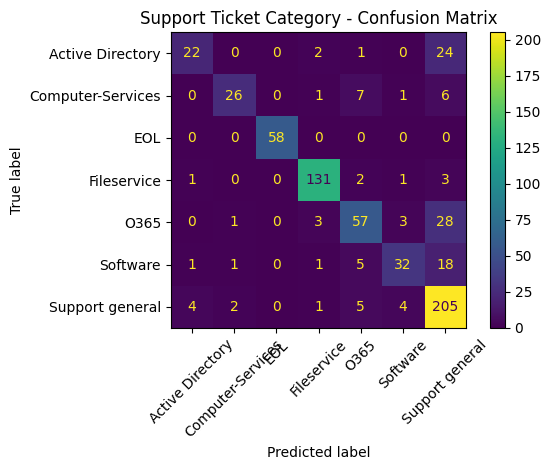


Priority labels created! ✅

Training priority distribution:
text
Medium    843
Low       668
High       61
Name: count, dtype: int64

Testing priority distribution:
text
Low       352
Medium    291
High       14
Name: count, dtype: int64

PRIORITY CLASSIFICATION

Training priority classifier...
Priority model trained successfully! ✅

PRIORITY MODEL RESULTS
----------------------------------------
Accuracy : 0.9559
Precision: 0.9585
Recall   : 0.9559
F1 Score : 0.9550

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.64      0.78        14
         Low       0.93      1.00      0.96       352
      Medium       0.99      0.92      0.95       291

    accuracy                           0.96       657
   macro avg       0.97      0.85      0.90       657
weighted avg       0.96      0.96      0.96       657



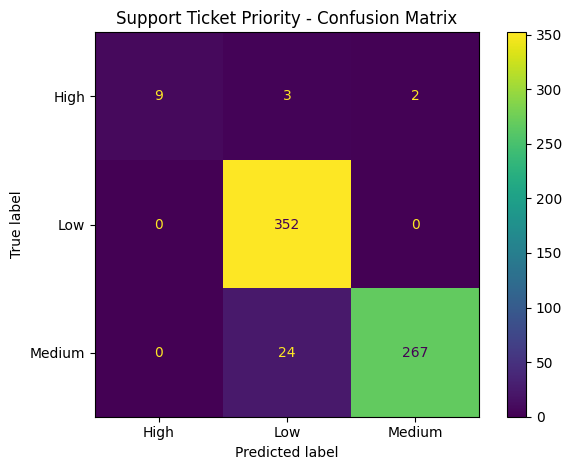


NEW TICKET PREDICTIONS

Ticket: The production server is down and all users cannot access the system.
Predicted Category: Support general
Predicted Priority: High

Ticket: I forgot my password and cannot login.
Predicted Category: Software
Predicted Priority: Medium

Ticket: The printer is not working in the office.
Predicted Category: Computer-Services
Predicted Priority: High

Ticket: The application has a critical security issue and may have been hacked.
Predicted Category: Support general
Predicted Priority: High

TASK 2 COMPLETED 🚀

Category Classification
Accuracy : 0.8082
Precision: 0.8143
Recall   : 0.8082
F1 Score : 0.7999

Priority Classification
Accuracy : 0.9559
Precision: 0.9585
Recall   : 0.9559
F1 Score : 0.955

Generated files:
✓ category_confusion_matrix.png
✓ priority_confusion_matrix.png
✓ ticket_predictions.csv
✓ model_metrics.csv
✓ category_classifier.pkl
✓ priority_classifier.pkl

Everything finished successfully! 🎉🔥


In [3]:
# ============================================================
# FUTURE_ML_02 - SUPPORT TICKET CLASSIFICATION
# CORRECTED VERSION
# ============================================================

import os
import re
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

import nltk
from nltk.corpus import stopwords

warnings.filterwarnings("ignore")


# ============================================================
# 1. NLTK
# ============================================================

try:
    stop_words = set(stopwords.words("english"))
except:
    nltk.download("stopwords")
    stop_words = set(stopwords.words("english"))

print("Libraries loaded successfully! ✅")


# ============================================================
# 2. LOAD DATA
# ============================================================

X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

print("\nDataset loaded successfully! 🚀")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nX_train columns:")
print(X_train.columns.tolist())

print("\ny_train columns:")
print(y_train.columns.tolist())


# ============================================================
# 3. AUTOMATICALLY FIND THE TICKET TEXT COLUMN
# ============================================================

# Find the column containing the longest average text.
# This avoids accidentally selecting an ID/index column.

text_scores = {}

for col in X_train.columns:
    values = X_train[col].fillna("").astype(str)

    # Average character length
    text_scores[col] = values.str.len().mean()

text_column = max(text_scores, key=text_scores.get)

label_column = "category_truth" 

print("\nDetected ticket text column:", text_column)
print("Detected category column:", label_column)

print("\nExample ticket:")
print(X_train[text_column].iloc[0])


# ============================================================
# 4. PREPARE DATA
# ============================================================

train_text = X_train[text_column].fillna("").astype(str)
test_text = X_test[text_column].fillna("").astype(str)

train_labels = y_train[label_column].fillna("").astype(str)
test_labels = y_test[label_column].fillna("").astype(str)


# ============================================================
# 5. TEXT CLEANING
# ============================================================

def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Keep alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove English stopwords
    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


print("\nCleaning ticket text...")

clean_train = train_text.apply(clean_text)
clean_test = test_text.apply(clean_text)

print("Text cleaning completed! ✅")


# ============================================================
# 6. CHECK THAT TEXT IS NOT EMPTY
# ============================================================

empty_train = (clean_train.str.len() == 0).sum()
empty_test = (clean_test.str.len() == 0).sum()

print("\nEmpty training documents:", empty_train)
print("Empty testing documents :", empty_test)

if empty_train > 0:
    clean_train = clean_train.replace("", "unknown_ticket")

if empty_test > 0:
    clean_test = clean_test.replace("", "unknown_ticket")


# ============================================================
# 7. CATEGORY CLASSIFICATION
# ============================================================

print("\n" + "=" * 60)
print("CATEGORY CLASSIFICATION")
print("=" * 60)

category_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 2),
            min_df=1,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC()
    )
])

print("\nTraining category classifier...")

category_model.fit(
    clean_train,
    train_labels
)

category_predictions = category_model.predict(clean_test)

print("Category model trained successfully! ✅")


# ============================================================
# 8. CATEGORY EVALUATION
# ============================================================

category_accuracy = accuracy_score(
    test_labels,
    category_predictions
)

category_precision = precision_score(
    test_labels,
    category_predictions,
    average="weighted",
    zero_division=0
)

category_recall = recall_score(
    test_labels,
    category_predictions,
    average="weighted",
    zero_division=0
)

category_f1 = f1_score(
    test_labels,
    category_predictions,
    average="weighted",
    zero_division=0
)

print("\nCATEGORY MODEL RESULTS")
print("-" * 40)

print(f"Accuracy : {category_accuracy:.4f}")
print(f"Precision: {category_precision:.4f}")
print(f"Recall   : {category_recall:.4f}")
print(f"F1 Score : {category_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        test_labels,
        category_predictions,
        zero_division=0
    )
)


# ============================================================
# 9. CATEGORY CONFUSION MATRIX
# ============================================================

os.makedirs("../outputs", exist_ok=True)

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    category_predictions,
    xticks_rotation=45
)

plt.title("Support Ticket Category - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../outputs/category_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. PRIORITY RULES
# ============================================================

# IMPORTANT:
# Zenodo provides CATEGORY labels.
# It does NOT provide High/Medium/Low priority labels.
#
# Therefore priority is derived using transparent rules.

HIGH_WORDS = [
    "urgent",
    "emergency",
    "critical",
    "immediately",
    "outage",
    "unavailable",
    "cannot access",
    "can't access",
    "not working",
    "stopped working",
    "server down",
    "system down",
    "security",
    "breach",
    "hacked",
    "virus",
    "malware",
    "data loss",
    "production down"
]

MEDIUM_WORDS = [
    "error",
    "problem",
    "issue",
    "failed",
    "failure",
    "slow",
    "unable",
    "login",
    "password",
    "network",
    "connection",
    "printer",
    "software",
    "update",
    "access"
]


def assign_priority(text):

    text = str(text).lower()

    high_score = 0
    medium_score = 0

    for word in HIGH_WORDS:
        if word in text:
            high_score += 1

    for word in MEDIUM_WORDS:
        if word in text:
            medium_score += 1

    if high_score >= 1:
        return "High"

    elif medium_score >= 1:
        return "Medium"

    else:
        return "Low"


train_priority = train_text.apply(assign_priority)
test_priority = test_text.apply(assign_priority)

print("\nPriority labels created! ✅")

print("\nTraining priority distribution:")
print(train_priority.value_counts())

print("\nTesting priority distribution:")
print(test_priority.value_counts())


# ============================================================
# 11. PRIORITY CLASSIFIER
# ============================================================

print("\n" + "=" * 60)
print("PRIORITY CLASSIFICATION")
print("=" * 60)

priority_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 2),
            min_df=1,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC()
    )
])

print("\nTraining priority classifier...")

priority_model.fit(
    clean_train,
    train_priority
)

priority_predictions = priority_model.predict(clean_test)

print("Priority model trained successfully! ✅")


# ============================================================
# 12. PRIORITY EVALUATION
# ============================================================

priority_accuracy = accuracy_score(
    test_priority,
    priority_predictions
)

priority_precision = precision_score(
    test_priority,
    priority_predictions,
    average="weighted",
    zero_division=0
)

priority_recall = recall_score(
    test_priority,
    priority_predictions,
    average="weighted",
    zero_division=0
)

priority_f1 = f1_score(
    test_priority,
    priority_predictions,
    average="weighted",
    zero_division=0
)

print("\nPRIORITY MODEL RESULTS")
print("-" * 40)

print(f"Accuracy : {priority_accuracy:.4f}")
print(f"Precision: {priority_precision:.4f}")
print(f"Recall   : {priority_recall:.4f}")
print(f"F1 Score : {priority_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        test_priority,
        priority_predictions,
        zero_division=0
    )
)


# ============================================================
# 13. PRIORITY CONFUSION MATRIX
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    test_priority,
    priority_predictions
)

plt.title("Support Ticket Priority - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../outputs/priority_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. SAVE PREDICTIONS
# ============================================================

results = pd.DataFrame({
    "Ticket": test_text,
    "Actual_Category": test_labels,
    "Predicted_Category": category_predictions,
    "Rule_Priority": test_priority,
    "Predicted_Priority": priority_predictions
})

results.to_csv(
    "../outputs/ticket_predictions.csv",
    index=False
)


# ============================================================
# 15. SAVE METRICS
# ============================================================

metrics = pd.DataFrame({
    "Model": [
        "Category Classification",
        "Priority Classification"
    ],
    "Accuracy": [
        category_accuracy,
        priority_accuracy
    ],
    "Precision": [
        category_precision,
        priority_precision
    ],
    "Recall": [
        category_recall,
        priority_recall
    ],
    "F1_Score": [
        category_f1,
        priority_f1
    ]
})

metrics.to_csv(
    "../outputs/model_metrics.csv",
    index=False
)


# ============================================================
# 16. SAVE MODELS
# ============================================================

os.makedirs("../models", exist_ok=True)

joblib.dump(
    category_model,
    "../models/category_classifier.pkl"
)

joblib.dump(
    priority_model,
    "../models/priority_classifier.pkl"
)


# ============================================================
# 17. TEST NEW TICKETS
# ============================================================

def predict_ticket(ticket):

    cleaned = clean_text(ticket)

    category = category_model.predict([cleaned])[0]

    priority = priority_model.predict([cleaned])[0]

    return category, priority


sample_tickets = [
    "The production server is down and all users cannot access the system.",
    "I forgot my password and cannot login.",
    "The printer is not working in the office.",
    "The application has a critical security issue and may have been hacked."
]


print("\n" + "=" * 60)
print("NEW TICKET PREDICTIONS")
print("=" * 60)

for ticket in sample_tickets:

    category, priority = predict_ticket(ticket)

    print("\nTicket:", ticket)
    print("Predicted Category:", category)
    print("Predicted Priority:", priority)


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("TASK 2 COMPLETED 🚀")
print("=" * 60)

print("\nCategory Classification")
print("Accuracy :", round(category_accuracy, 4))
print("Precision:", round(category_precision, 4))
print("Recall   :", round(category_recall, 4))
print("F1 Score :", round(category_f1, 4))

print("\nPriority Classification")
print("Accuracy :", round(priority_accuracy, 4))
print("Precision:", round(priority_precision, 4))
print("Recall   :", round(priority_recall, 4))
print("F1 Score :", round(priority_f1, 4))

print("\nGenerated files:")
print("✓ category_confusion_matrix.png")
print("✓ priority_confusion_matrix.png")
print("✓ ticket_predictions.csv")
print("✓ model_metrics.csv")
print("✓ category_classifier.pkl")
print("✓ priority_classifier.pkl")

print("\nEverything finished successfully! 🎉🔥")

In [2]:
import pandas as pd

y_train = pd.read_csv("../data/y_train.csv")

print(y_train.columns.tolist())
print(y_train.head(10))

['id', 'category_truth']
     id   category_truth
0  1919      Fileservice
1  1584      Fileservice
2   584  Support general
3  1393  Support general
4  8636      Fileservice
5  1033  Support general
6  2248      Fileservice
7  3017      Fileservice
8  6671         Software
9  1892  Support general
